In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA

# Define font for plots
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Palatino', 'DejaVu Serif']

## Dataset Exploration

### LDA

In [24]:
selected_n_value = 10

X = np.load(f'datasets/kryptonite-{selected_n_value}-X.npy')
y = np.load(f'datasets/kryptonite-{selected_n_value}-y.npy')

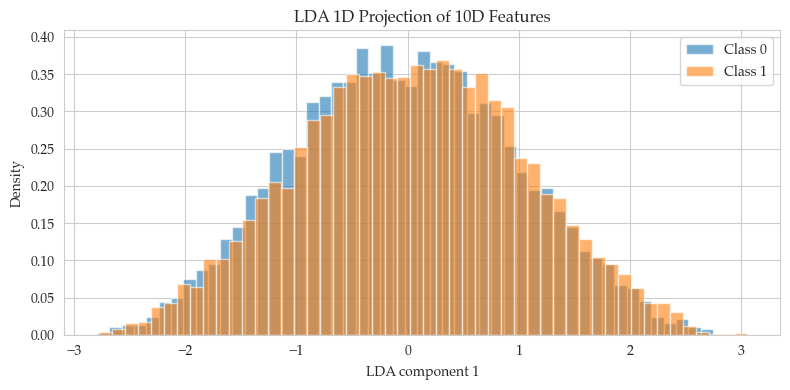

In [25]:
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y) 

proj = X_lda[:, 0]

class0 = proj[y == 0]
class1 = proj[y == 1]

plt.figure(figsize=(8, 4))
plt.hist(class0, bins=50, alpha=0.6, density=True, label="Class 0")
plt.hist(class1, bins=50, alpha=0.6, density=True, label="Class 1")
plt.xlabel("LDA component 1")
plt.ylabel("Density")
plt.title("LDA 1D Projection of 10D Features")
plt.legend()
plt.tight_layout()
plt.savefig('visualisations/LDA_hist.png')
plt.show()

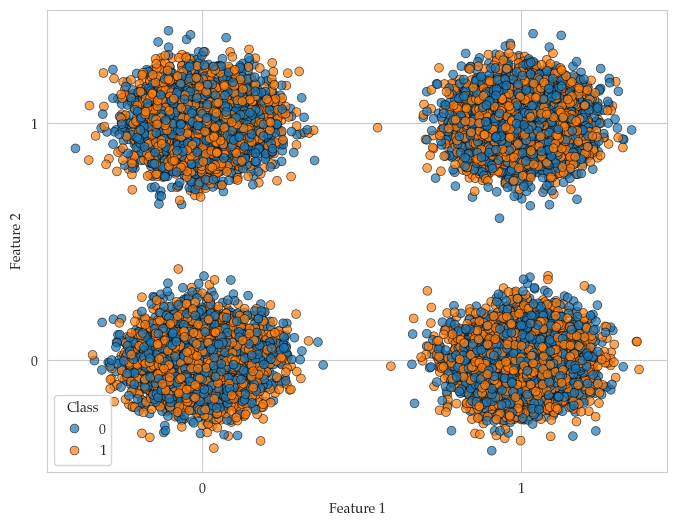

In [26]:
feature_names = [f"Feature_{i+1}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df["Class"] = y

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Feature_1", y="Feature_2", hue="Class", alpha=0.7, s=40, edgecolor="k")
plt.xlabel("Feature 1")
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.ylabel("Feature 2")
plt.savefig('visualisations/feature1_vs_feature2.png', bbox_inches="tight")
plt.show()

### PCA

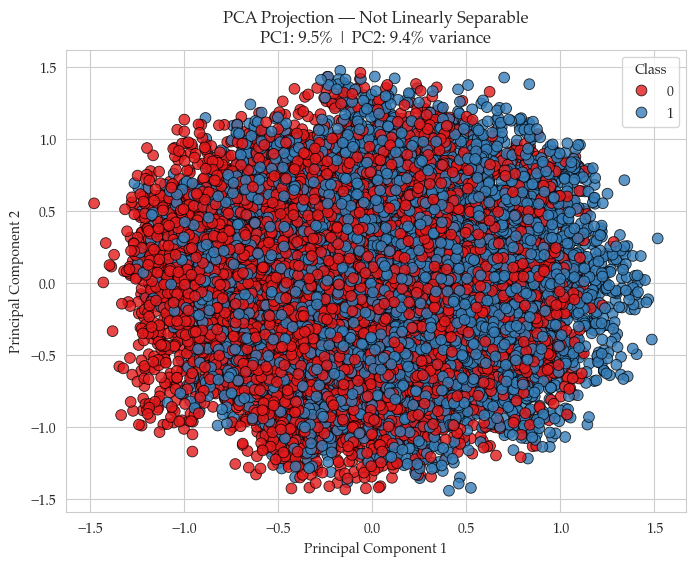

In [27]:
# Keep 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df)
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Class"] = y

# Get explained variance percentages
explained_var = pca.explained_variance_ratio_ * 100

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca, x="PC1", y="PC2", hue="Class",
    palette="Set1", s=60, alpha=0.8, edgecolor="k"
)
plt.title(f"PCA Projection — Not Linearly Separable\nPC1: {explained_var[0]:.1f}% | PC2: {explained_var[1]:.1f}% variance")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.savefig("visualisations/PCA_projection.png", bbox_inches="tight")
plt.show()

## kNN Model Evaluation

In [28]:
def import_dataset_n(n):
    X = np.load(f'datasets/kryptonite-{n}-X.npy')
    Y = np.load(f'datasets/kryptonite-{n}-y.npy')
    return X, Y

results = {}

for n in range(10, 21, 2):
    X, y = import_dataset_n(n)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
    
    results[str(n)] = {"k": 0, "cv_accuracy": -np.inf}
    
    # Find best k using 5-fold CV on training set
    for k in range(1, 8):
        knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
        scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
        mean_acc = round(np.mean(scores),3)
        
        if mean_acc > results[str(n)]['cv_accuracy']:
            results[str(n)]['k'] = k
            results[str(n)]['cv_accuracy'] = mean_acc
    
    # Final evaluation: train on full training set, test once
    best_k = results[str(n)]['k']
    knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
    knn.fit(X_train, y_train)
    
    y_test_pred = knn.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    results[str(n)]['test_accuracy'] = test_accuracy
    
df = pd.DataFrame(results).T
df.index.name = 'n_neighbors'
print(df)

               k  cv_accuracy  test_accuracy
n_neighbors                                 
10           5.0        0.961       0.959000
12           1.0        0.921       0.923056
14           1.0        0.785       0.822381
16           1.0        0.547       0.593542
18           1.0        0.475       0.471111
20           1.0        0.488       0.490000


## MLP Model Evaluation

We load in the stored trained model results from *model_training.ipynb* for evaluation. For further explanation please see the README.md.

For features n=10
Hyperparameters Chosen: lr=0.001, bs=64 Test accuracy (averaged over seeds): 0.963 ± 0.000
For features n=12
Hyperparameters Chosen: lr=0.001, bs=64 Test accuracy (averaged over seeds): 0.958 ± 0.001
For features n=14
Hyperparameters Chosen: lr=0.001, bs=64 Test accuracy (averaged over seeds): 0.964 ± 0.000
For features n=16
Hyperparameters Chosen: lr=0.001, bs=64 Test accuracy (averaged over seeds): 0.931 ± 0.010
For features n=18
Hyperparameters Chosen: lr=0.001, bs=64 Test accuracy (averaged over seeds): 0.858 ± 0.004
For features n=20
Hyperparameters Chosen: lr=0.001, bs=64 Test accuracy (averaged over seeds): 0.789 ± 0.006


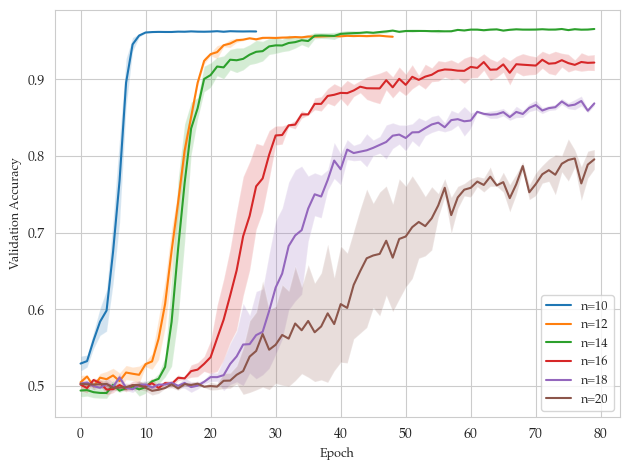

In [ ]:
best_model_per_n = {}

for n in [10, 12, 14, 16, 18, 20]:  
    kryptonite_model_results = torch.load(f'models/results_{n}', weights_only=False)
    best_idx = kryptonite_model_results['best_idx']
    best_results =kryptonite_model_results['results'][best_idx]

    best_configs = best_results['config']

    best_result_per_seed = [x for x in kryptonite_model_results['results'] if x['config']['lr'] == best_configs['lr'] and x['config']['train_bs'] == best_configs['train_bs']]


    mean_test_acc =  np.mean([x['test_acc'] for x in best_result_per_seed])
    stdev_test_acc =  np.std([x['test_acc'] for x in best_result_per_seed])

    min_len = min(len(x['history']['val_acc']) for x in best_result_per_seed)
    val_acc_curves = np.array([x['history']['val_acc'][:min_len] for x in best_result_per_seed])

    mean_validation_acc_curve = np.mean(val_acc_curves, axis=0)
    stdev_validation_acc_curve =  np.std(val_acc_curves, axis=0)

    print(f"For features n={n}")
    print(f"Hyperparameters Chosen: lr={best_configs['lr']}, bs={best_configs['train_bs']} Test accuracy (averaged over seeds): {mean_test_acc:.3f} ± {stdev_test_acc:.3f}")
    
    best_model_per_n[n] = {
        'config': best_configs,  
        'val_acc_curve': mean_validation_acc_curve,
        'val_acc_std': stdev_validation_acc_curve,
        'test_acc': mean_test_acc,
        'test_acc_std': stdev_test_acc,
    }
    
plt.figure()

for n, info in sorted(best_model_per_n.items()):
    cfg = info['config']
    label = f"n={n}"
    epochs = np.arange(len(info['val_acc_curve']))
    plt.plot(epochs, info['val_acc_curve'], label=label)
    plt.fill_between(epochs, info['val_acc_curve'] - info['val_acc_std'], info['val_acc_curve'] + info['val_acc_std'], alpha=0.2)

plt.xlabel("Epoch", fontsize=9)
plt.ylabel("Validation Accuracy", fontsize=9)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('visualisations/validation_accuracy_per_n')
plt.show()
    

LR=0.001, BS=64: best_val_acc=0.963 (epoch 21), ±0.000
LR=0.001, BS=256: best_val_acc=0.962 (epoch 25), ±0.000
LR=0.003, BS=64: best_val_acc=0.962 (epoch 10), ±0.000
LR=0.003, BS=256: best_val_acc=0.962 (epoch 19), ±0.001
LR=0.01, BS=64: best_val_acc=0.961 (epoch 29), ±0.000
LR=0.01, BS=256: best_val_acc=0.961 (epoch 15), ±0.001


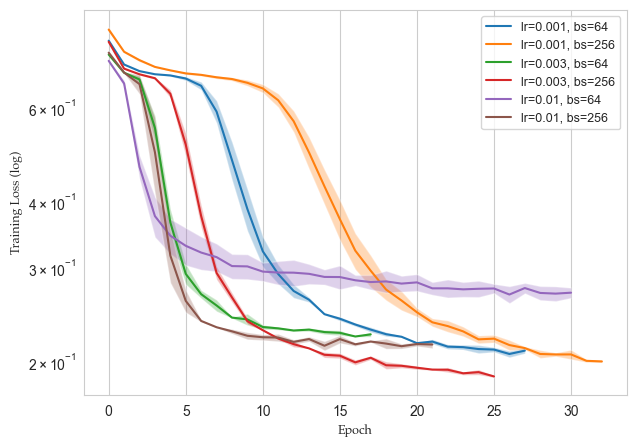

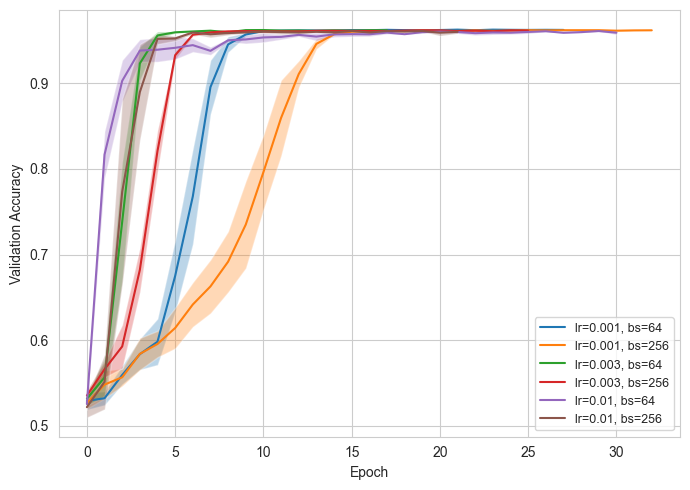

In [30]:
selected_n_value = 10
kryptonite_model_results = torch.load(f'models/results_{selected_n_value}', weights_only=False)

sns.set_style("whitegrid")

#Figure 1 is training loss
fig1, ax1 = plt.subplots(figsize=(7,5))  

#Figure 2 is validation accuracy
fig2, ax2 = plt.subplots(figsize=(7,5))   

# Group results by (lr, bs)
grouped = defaultdict(list)

for r in kryptonite_model_results['results']:
    lr = r['config']['lr']
    bs = r['config']['train_bs']
    grouped[(lr, bs)].append(r)

# Plot averaged curves per (lr, bs)
for (lr, bs), runs in grouped.items():


    min_len = min(len(x['history']['val_acc']) for x in runs)
    train_losses = np.array([x['history']['train_loss'][:min_len] for x in runs])
    val_accs = np.array([x['history']['val_acc'][:min_len] for x in runs])

    # Average across seeds
    train_loss_mean = np.mean(train_losses, axis=0)
    val_acc_mean = np.mean(val_accs, axis=0)

    train_loss_std = np.std(train_losses, axis=0)
    val_acc_std = np.std(val_accs, axis=0)
    
    label = f"lr={lr}, bs={bs}"
    
    # Plot means with shaded std region
    epochs = np.arange(len(train_loss_mean))
    ax1.plot(epochs, train_loss_mean, label=label)
    ax1.fill_between(epochs, train_loss_mean - train_loss_std, train_loss_mean + train_loss_std, alpha=0.3)
    
    ax2.plot(epochs, val_acc_mean, label=label)
    ax2.fill_between(epochs, val_acc_mean - val_acc_std, val_acc_mean + val_acc_std, alpha=0.3)
    
    #Print results for each hyperparam pair
    best_val_acc = np.max(val_acc_mean)
    best_epoch = np.argmax(val_acc_mean)
    print(f"LR={lr}, BS={bs}: best_val_acc={best_val_acc:.3f} (epoch {best_epoch}), "f"±{val_acc_std[best_epoch]:.3f}")

ax1.set_yscale("log")
ax1.set_xlabel("Epoch", fontsize=9, font='serif')
ax1.set_ylabel("Training Loss (log)", fontsize=9,  font='serif')
ax1.legend(fontsize=9)
ax1.figure.savefig(f'visualisations/training_loss_{selected_n_value}.png', bbox_inches='tight', dpi=300)

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation Accuracy")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()